In [1]:
import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import fetch_california_housing
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

 
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42                                           

### Task 13 — Toolkit v2

Extend the functions from Task 7 to support dropout regularization and real-world datasets.

1. **`set_seed(seed)`**: Sets the random seed across `random`, `numpy`, and `tensorflow` to ensure experiment reproducibility.
2. **`build_model(input_dim, hidden_layers, activation, dropout_rate, output_units, output_activation)`**: Constructs an MLP model, adding a `Dropout(dropout_rate)` layer after each hidden layer only when `dropout_rate > 0`.
3. **`train_model(model, X_train, y_train, epochs, loss, metrics, patience)`**: Compiles and fits the model; when `patience` is provided, attaches `EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)`.
4. **`results_table(rows)`**: Converts a list of result dictionaries into a sorted pandas `DataFrame`.
5. **`plot_histories(histories, metric)`**: Plots the selected metric across multiple models on a single comparison chart.

In [2]:
def set_seed(seed=42):
    """Set seed for random, numpy and torch"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)             
    torch.cuda.manual_seed_all(seed)   


set_seed(SEED)

In [3]:
ACTIVATIONS = {"relu": nn.ReLU, "tanh": nn.Tanh, "sigmoid": nn.Sigmoid, "elu": nn.ELU}


def get_activation(name) -> None | Softmax | Any:
    """Maps an activation name to a PyTorch layer; returns None for None and 'linear'."""
    if name in (None, "linear"):
        return None
    if name == "softmax":
        return nn.Softmax(dim=1)
    return ACTIVATIONS[name]()

In [4]:
def make_hidden_block(in_features, units, activation, dropout_rate) -> list[Linear]:
    """Single hidden layer: Linear -> activation -> Dropout (only when dropout_rate > 0)."""
    block = [nn.Linear(in_features, units)]
    
    if get_activation(activation) is not None:
        block.append(get_activation(activation))
    
    if dropout_rate > 0:
        block.append(nn.Dropout(dropout_rate))
    
    return block

In [5]:
def make_output_block(in_features, output_units, output_activation) -> list[Linear]:

    block = [nn.Linear(in_features, output_units)]
    
    if get_activation(output_activation) is not None:
        block.append(get_activation(output_activation))
    
    return block

In [6]:
def build_model(input_dim, hidden_layers, activation="relu", dropout_rate=0.0,
                output_units=1, output_activation=None) -> Sequential:
    """Builds a network from hidden_layers and an output layer.

    hidden_layers=[] yields a linear model (output layer only).
    """
    layers = []
    in_features = input_dim
    
    for units in hidden_layers:
        layers += make_hidden_block(in_features, units, activation, dropout_rate)
        in_features = units                  
    
    layers += make_output_block(in_features, output_units, output_activation)
    
    return nn.Sequential(*layers).to(DEVICE)

In [7]:
def count_params(model):
    """Number of params in models."""
    return sum(p.numel() for p in model.parameters())

In [8]:
example = build_model(input_dim=8, hidden_layers=[64, 32], dropout_rate=0.2)
print(example)
print("Num of params", count_params(example))
print

Sequential(
  (0): Linear(in_features=8, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=64, out_features=32, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.2, inplace=False)
  (6): Linear(in_features=32, out_features=1, bias=True)
)
Num of params 2689


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [9]:
# Same model in keras:
# model = keras.Sequential([
#    keras.Input(shape=(8,)),
#    layers.Dense(64, activation="relu"),
#    layers.Dropout(0.2),
#    layers.Dense(32, activation="relu"),
#    layers.Dropout(0.2),
#    layers.Dense(1),
# ])
# model.summary()   # Total params: 8*64 + 64*32+32 + 32*1+1 = 2,689

Unlike Keras, which encapsulates the entire pipeline within `fit()`, PyTorch breaks training down into explicit, modular steps:

1. **`to_tensors`**: Convert NumPy arrays to `float32` tensors; reshape target `y` from `(N,)` to `(N, 1)` to match the model's output dimensions.
2. **`split_validation`**: Allocate the final 20% of data for validation (identical to `validation_split` in Keras).
3. **`make_loader`**: Wrap training data into a `DataLoader` to shuffle and generate batches of 32 samples.
4. **`train_step`**: Execute a single optimization step: zero gradients → forward pass → compute loss → backward pass (`loss.backward()`) → update weights (`optimizer.step()`).
5. **`train_one_epoch`**: Run `train_step` across all training batches with dropout active (`model.train()`).
6. **`evaluate_loss`**: Compute validation loss with dropout disabled (`model.eval()`) and gradient calculation turned off (`torch.no_grad()`).
7. **`EarlyStopping`**: Track the best model state and halt execution when `val_loss` fails to improve for `patience` consecutive epochs.
8. **`train_model`**: Coordinate steps 1–7 and return the training history dictionary: `{'loss': [...], 'val_loss': [...], ...}`.

In [72]:
def to_tensors(X, y, loss):
    """numpy -> tensors: long class indices for multiclass, float (N, 1) otherwise."""
    X = torch.as_tensor(np.array(X), dtype=torch.float32)
    y = np.array(y)
    if loss == "sparse_categorical_crossentropy":
        return X, torch.as_tensor(y, dtype=torch.long)                           # (N,) class indices
    return X, torch.as_tensor(y, dtype=torch.float32).reshape(len(y), -1)        # (N, 1)


def split_validation(X, y, validation_split):
    """Splits off the LAST validation_split fraction of data as the validation set (identical to Keras validation_split)."""
    n_train = len(X) - int(len(X) * validation_split)
    return (X[:n_train], y[:n_train]), (X[n_train:], y[n_train:])


def make_loader(X, y, batch_size):
    """Splits data into shuffled batches of size batch_size."""
    return DataLoader(TensorDataset(X, y), batch_size=batch_size, shuffle=True)

In [71]:
LOSSES = {
    "mse": nn.MSELoss,
    "mae": nn.L1Loss,
    "binary_crossentropy": nn.BCEWithLogitsLoss,               # 2 classes, sigmoid inside the loss
    "sparse_categorical_crossentropy": nn.CrossEntropyLoss,    # many classes, softmax inside the loss
}

def get_loss_fn(name):
    """Keras-style loss name ('mse', 'mae', ...) -> PyTorch loss function."""
    return LOSSES[name]()


def compute_metric(name, output, y):
    """Value of one metric ('mae', 'mse' or 'accuracy') for the model output."""
    if name == "mae":
        return (output - y).abs().mean().item()
    if name == "mse":
        return ((output - y) ** 2).mean().item()
    if name == "accuracy" and output.shape[1] == 1:              # binary: logit > 0 <=> p > 0.5
        return ((output > 0).float() == y).float().mean().item()
    if name == "accuracy":                                       # multiclass: highest score wins
        return (output.argmax(dim=1) == y).float().mean().item()
    raise ValueError(f"Unknown metric: {name}")


def compute_logs(loss_value, metrics, output, y):
    """Dictionary {'loss': ..., 'mae': ...}, mimicking Keras epoch output logs."""
    logs = {"loss": loss_value}
    for name in metrics:
        logs[name] = compute_metric(name, output, y)
    return logs

In [12]:
def train_step(model, xb, yb, loss_fn, optimizer):
    """Single training step on a single batch. Returns model output and loss value."""
    optimizer.zero_grad()  # 1. Clear gradients from previous step (otherwise they accumulate)
    output = model(xb)  # 2. Forward pass / predictions
    loss = loss_fn(output, yb)  # 3. Compute loss
    loss.backward()  # 4. Backpropagation: compute gradients w.r.t. weights
    optimizer.step()  # 5. Update weights
    return output.detach(), loss.item()


def train_one_epoch(model, loader, loss_fn, optimizer, metrics):
    """Single training epoch with dropout ENABLED. Returns average logs across all batches."""
    model.train()  # Training mode: dropout active
    sums, n_seen = {}, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        output, loss = train_step(model, xb, yb, loss_fn, optimizer)
        for key, value in compute_logs(loss, metrics, output, yb).items():
            sums[key] = (
                sums.get(key, 0.0) + value * len(xb)
            )  # Weighted by batch size
        n_seen += len(xb)
    return {key: total / n_seen for key, total in sums.items()}


def evaluate_loss(model, X, y, loss_fn, metrics):
    """Computes loss and metrics on a dataset with dropout DISABLED and autograd turned off."""
    model.eval()  # Evaluation mode: dropout disabled
    with torch.no_grad():
        X, y = X.to(DEVICE), y.to(DEVICE)
        output = model(X)
        return compute_logs(loss_fn(output, y).item(), metrics, output, y)

In [13]:
class EarlyStopping:
    """PyTorch equivalent of EarlyStopping(monitor='val_loss', patience=..., restore_best_weights=True)."""

    def __init__(self, patience):
        self.patience = patience
        self.best_loss = float("inf")
        self.best_weights = None
        self.bad_epochs = 0  # number of consecutive epochs without improvement

    def should_stop(self, val_loss, model):
        """Saves weights when val_loss improves; returns True when training should stop."""
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.best_weights = copy.deepcopy(model.state_dict())
            self.bad_epochs = 0
            return False
        self.bad_epochs += 1
        return self.bad_epochs >= self.patience

    def restore(self, model):
        """Loads the best-saved weights back into the model."""
        if self.best_weights is not None:
            model.load_state_dict(self.best_weights)

In [73]:
def append_history(history, logs, prefix=""):
    """Appends single-epoch logs to the history dict; prefix='val_' for validation."""
    for key, value in logs.items():
        history.setdefault(prefix + key, []).append(value)


def train_model(
    model,
    X_train,
    y_train,
    epochs=100,
    loss="mse",
    metrics=("mae",),
    patience=None,
    batch_size=32,
    validation_split=0.2,
    lr=1e-3,
):
    """Trains the model (equivalent to compile + fit). Returns a history dict like Keras history.history.

    patience=None: disables early stopping.
    patience=int: EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True).
    """
    loss_fn = get_loss_fn(loss)
    optimizer = torch.optim.Adam(
        model.parameters(), lr=lr
    )  # Keras-style 'adam', lr=0.001

    X, y = to_tensors(X_train, y_train, loss)          # <- dodaj argument loss
    (X_tr, y_tr), (X_val, y_val) = split_validation(X, y, validation_split)
    loader = make_loader(X_tr, y_tr, batch_size)
    has_val = len(X_val) > 0                           # <- nowe: czy jest walidacja
    stopper = EarlyStopping(patience) if patience is not None and has_val else None

    history = {}
    for _ in range(epochs):
        append_history(history, train_one_epoch(model, loader, loss_fn, optimizer, metrics))
        if has_val:                                    # <- nowe: walidacja tylko gdy jest
            append_history(history, evaluate_loss(model, X_val, y_val, loss_fn, metrics), prefix="val_")
        if stopper and stopper.should_stop(history["val_loss"][-1], model):
            break

    if stopper:
        stopper.restore(model)  # restore_best_weights=True
    return history


def predict(model, X):
    """Returns single-output model predictions as a 1D NumPy array (supports PyTorch or scikit-learn models)."""
    if not isinstance(model, nn.Module):  # scikit-learn models use their own .predict()
        return model.predict(X)
    model.eval()  # disables dropout and batchnorm, matching Keras predict()
    with torch.no_grad():
        X = torch.as_tensor(np.asarray(X), dtype=torch.float32).to(DEVICE)
        return model(X).cpu().numpy().ravel()

def predict_logits(model, X):
    """Raw network outputs (logits) with dropout OFF and without gradients."""
    model.eval()
    with torch.no_grad():
        X = torch.as_tensor(np.asarray(X), dtype=torch.float32).to(DEVICE)
        return model(X).cpu()


def predict_proba(model, X):
    """Binary: probability of class 1, shape (N,). Multiclass: probabilities, shape (N, classes)."""
    if not isinstance(model, nn.Module):                     # sklearn model
        proba = model.predict_proba(X)
        return proba[:, 1] if proba.shape[1] == 2 else proba
    logits = predict_logits(model, X)
    if logits.shape[1] == 1:
        return torch.sigmoid(logits).numpy().ravel()          # binary
    return torch.softmax(logits, dim=1).numpy()               # multiclass


def predict_labels(model, X, threshold=0.5):
    """Predicted classes: binary uses the threshold, multiclass takes the most probable class."""
    proba = predict_proba(model, X)
    if proba.ndim == 1:
        return (proba >= threshold).astype(int)
    return proba.argmax(axis=1)

In [15]:
def results_table(rows, sort_by="MAE", ascending=True):
    """Converts a list of results (one dictionary per model) into a table sorted by sort_by."""
    table = pd.DataFrame(rows).sort_values(sort_by, ascending=ascending)
    return table.reset_index(drop=True).round(4)

In [16]:
def plot_histories(histories, metric="loss", show_train=True, show_val=True,
                   logy=False, title=None, ax=None):
    """Plots a metric across multiple model histories on a single plot.
    
    histories: {model_name: history from train_model}.
    Color = model, solid line = train, dashed line = validation.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 5))
    for i, (name, history) in enumerate(histories.items()):
        color = f"C{i % 10}"                    
        if show_train:
            ax.plot(history[metric], color=color, label=f"{name}: {metric}")
        if show_val:
            ax.plot(history[f"val_{metric}"], color=color, linestyle="--",
                    label=f"{name}: val_{metric}")
    if logy:
        ax.set_yscale("log")
    ax.set_xlabel("epoka")
    ax.set_ylabel(metric)
    ax.set_title(title or metric)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    return ax

# exercise 14 

Regression on Real-World Data

Dataset: California Housing (`fetch_california_housing`).

1. Write `load_housing_data()` to fetch the dataset, perform a train/test split, and scale feature matrix `X` using `StandardScaler`.
2. Train a `[64, 32]` architecture with ReLU activations for 100 epochs. Plot its training and validation history.
3. Train the exact same architecture on unscaled raw data. Compare both learning curves side-by-side.
4. Establish baselines: `DummyRegressor(strategy='mean')` and `Ridge()`. Evaluate and report test MAE and $R^2$ for all three models.
5. Answer: Why does omitting feature scaling degrade training dynamics so severely? Did the neural network outperform linear regression, and by what margin?

In [17]:
def load_raw_housing():
    # catching california data
    data = fetch_california_housing()
    return data.data, data.target

def split_data(X, y, test_size = 0.2, stratify = False):
    # splitting the data
    return train_test_split(X, y, test_size=test_size, random_state=SEED,
                            stratify=y if stratify else None)

def scale_features(X_train, X_test):
    # scaling the data
    scaler = StandardScaler().fit(X_train)
    return scaler.transform(X_train), scaler.transform(X_test)
    
def load_housing_data(scale = True):

    X, y = load_raw_housing()
    X_train, X_test, y_train, y_test = split_data(X, y)
    if scale:
        X_train, X_test = scale_features(X_train, X_test)
    return X_train, X_test, y_train, y_test

def to_dataframe(X, y=None):

    df = pd.DataFrame(X, columns=fetch_california_housing().feature_names)
    if y is not None:
        df["MedHouseVal"] = y
    return df

In [18]:
X_train, X_test, y_train, y_test = load_housing_data()

In [19]:
X_train, X_test, y_train, y_test = load_housing_data(scale=True)    
X_train_raw, X_test_raw, _, _ = load_housing_data(scale=False)     

df_raw = to_dataframe(X_train_raw, y_train)
df_raw.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03,1.030
1,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16,3.821
2,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48,1.726
3,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11,0.934
4,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80,0.965


### 14.2 Neural Network on Scaled Data
- Set the random seed and build a `[64, 32]` network with ReLU.
- Train for 100 epochs: MSE loss, MAE metric, 20% validation split.
- Plot `loss` and `val_loss`.

In [20]:
set_seed(SEED)

In [21]:
model_scaled = build_model(input_dim=X_train.shape[1], hidden_layers=[64, 32], activation="relu")
hist_scaled = train_model(model_scaled, X_train, y_train, epochs=100, loss="mse", metrics=["mae"])

### Why `loss="mse"` and `metrics=["mae"]`?

**Loss is for the network, the metric is for humans.**

- **Loss (MSE)** is the number the network minimizes during training.
  
  - It squares the error, so big mistakes are punished much harder than small ones: an error of 2 costs 4, an error of 10 costs 100.
    
  - Its gradient is proportional to the error. Big mistakes give big corrections, small mistakes give gentle ones, which keeps training smooth.
    
  - Downside: the value is in squared units ((100k $)²), so it is hard to interpret.
    
-  **Metric (MAE)**  is only computed and reported; the network does not learn from it.
  
  - It is the average error in the same units as the price.

  - MAE = 0.4 means the model is off by about 40k $ on average. You can say that to someone outside ML.

**Remember:** MSE is convenient for training, MAE is convenient for reading results.

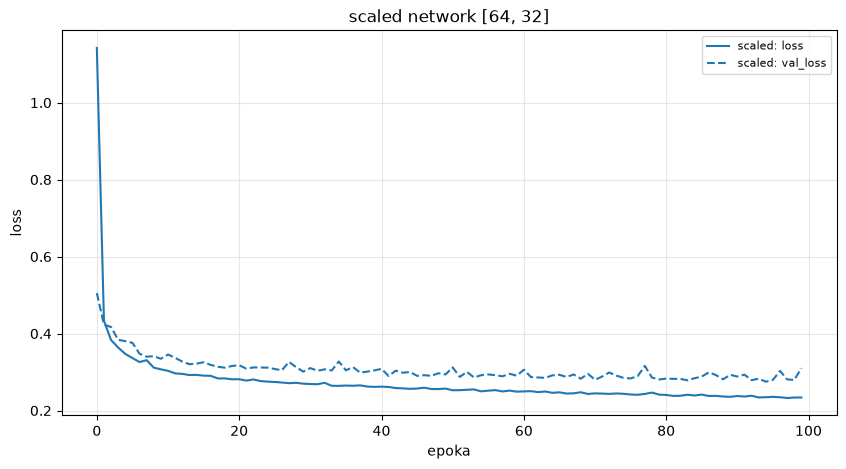

In [22]:
plot_histories({"scaled": hist_scaled}, metric="loss", title="scaled network [64, 32]")
plt.show()

### 14.3 The Same Model on Unscaled Data
- Same random seed and identical architecture; only the input data changes.
- Two side-by-side plots on a logarithmic scale, as the loss on raw data can be orders of magnitude larger.

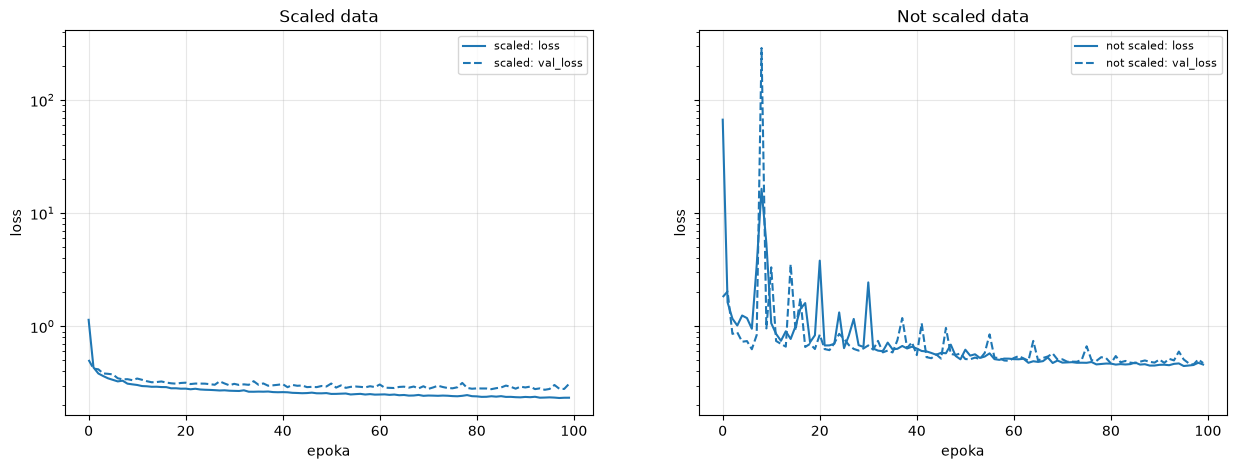

In [23]:
set_seed(SEED)
model_raw = build_model(X_train_raw.shape[1], [64, 32], activation="relu")
hist_raw = train_model(model_raw, X_train_raw, y_train, epochs=100, loss="mse", metrics=["mae"])

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
plot_histories({"scaled": hist_scaled}, logy=True, title="Scaled data", ax=axes[0])
plot_histories({"not scaled": hist_raw}, logy=True, title="Not scaled data", ax=axes[1])
plt.show()

**Result:** without scaling, training is unstable rather than overfitted. Loss and val_loss stay close to each other, but both jump around (val_loss spikes to ~300 around epoch 8), and after 100 epochs the loss is ~0.5 compared with ~0.24 on scaled data, so the unscaled model is about twice as bad and needs far more epochs to settle.

### 14.4 Baseline Models and Comparison
- `fit_baselines` trains `DummyRegressor(strategy='mean')` (always predicts the mean) and `Ridge()` (linear regression).
- `evaluate_regressor` computes test MAE and R²; works identically for both neural networks and scikit-learn models.
- `percent_better` indicates the percentage by which the neural network's MAE is lower than Ridge's.

In [24]:
def fit_baselines(X_train, y_train):
    # train dummy regressor and ridge (reg lin)
    return {
        "Dummy": DummyRegressor(strategy="mean").fit(X_train, y_train),
        "Ridge": Ridge().fit(X_train, y_train),
    }

def evaluate_regressor(model, X_test, y_test):
    # mae and r2 on test set"
    y_pred = predict(model, X_test)
    return {"MAE": mean_absolute_error(y_test, y_pred), "R_2": r2_score(y_test, y_pred)}




In [25]:
baselines = fit_baselines(X_train, y_train)

rows_models = [
    {"model": "Network [64, 32], scaled", **evaluate_regressor(model_scaled, X_test, y_test)},
    {"model": "Network [64, 32], not scaled", **evaluate_regressor(model_raw, X_test_raw, y_test)},
    {"model": "Ridge", **evaluate_regressor(baselines["Ridge"], X_test, y_test)},
    {"model": "Dummy", **evaluate_regressor(baselines["Dummy"], X_test, y_test)},
]

In [26]:
table_models = results_table(rows_models, sort_by="MAE")
table_models

,model,MAE,R_2
0,"Network [64, 32], scaled",0.3982,0.7646
1,"Network [64, 32], not scaled",0.5024,0.6404
2,Ridge,0.5332,0.5758
3,Dummy,0.9061,-0.0002


network with scaled data has the best results

Feature scaling prevents features with large ranges from dominating gradient updates, yet the linear regression did not outperform nn.

# exercise 15

Network Capacity and Overfitting

Evaluate generalization capacity by deliberately forcing the model to overfit.

1. Subsample the training set to 1,000 examples (overfitting on the full dataset is difficult to observe).
2. Benchmark the following architectures: `[]`, `[16]`, `[64, 64]`, `[256, 256, 256]`, and `[512, 512, 512, 512]` — all without dropout, trained for 300 epochs without Early Stopping.
3. In a summary table, report: total parameter count, final training loss, final validation loss, the generalization gap (`val_loss - loss`), and test MAE.
4. Plot the validation loss curves of all models on a single comparison figure.

In [27]:
def take_subset(X, y, n):
    """Samples n examples without replacement (fixed seed -> always the same)."""
    idx = np.random.default_rng(SEED).choice(len(X), size=n, replace=False)
    return X[idx], y[idx]

X_small, y_small = take_subset(X_train, y_train, n=1000)
print("Small training data set:", X_small.shape)

Small training data set: (1000, 8)


### 15.2 Building and Training Models
- `build_models` takes a `{name: build_model_settings}` dictionary and constructs a model for each entry.
- `train_models` trains each model using the same configuration and returns a history dictionary.
- We reuse these same two functions in Task 16; only the configuration dictionary changes.

In [28]:
def build_models(specs, input_dim):
    # builds one model for each entry in specs = {name: build_model arguments}
    return {name: build_model(input_dim, **settings) for name, settings in specs.items()}

### How `build_models` works

**One function, many models:** it takes a dictionary of settings and calls `build_model` for each entry.

- **Input `specs`:** a dictionary `{model name: settings}`, e.g.
  `{"[16]": {"hidden_layers": [16]}, "[64, 64]": {"hidden_layers": [64, 64]}}`
- **Loop:** `for name, settings in specs.items()` takes each name with its settings.
- **`**settings`** unpacks the dictionary into function arguments:
  `build_model(8, **{"hidden_layers": [16]})` is the same as `build_model(8, hidden_layers=[16])`.
- **Output:** a dictionary `{model name: built model}`, e.g. `{"[16]": model, "[64, 64]": model}`.

The same thing written as a regular loop:

    models = {}
    for name, settings in specs.items():
        models[name] = build_model(input_dim, **settings)
    return models

**Why?** Task 15 changes the network size and task 16 changes dropout, but the function stays the same. Only the `specs` dictionary changes.

In [29]:
def train_models(models, X_train, y_train, epochs, patience=None, loss="mse",
                 metrics=("mae",), validation_split=0.2):
    """Trains every model with the same settings; returns {name: history}."""
    histories = {}
    for name, model in models.items():
        print(f"Training: {name}")
        histories[name] = train_model(model, X_train, y_train, epochs=epochs, patience=patience,
                                      loss=loss, metrics=metrics, validation_split=validation_split)
    return histories

In [30]:
CONFIGS_15 = [[], [16], [64, 64], [256, 256, 256], [512, 512, 512, 512]]

specs15 = {}
for config in CONFIGS_15:
    specs15[str(config)] = {"hidden_layers": config}
specs15

{'[]': {'hidden_layers': []},
 '[16]': {'hidden_layers': [16]},
 '[64, 64]': {'hidden_layers': [64, 64]},
 '[256, 256, 256]': {'hidden_layers': [256, 256, 256]},
 '[512, 512, 512, 512]': {'hidden_layers': [512, 512, 512, 512]}}

In [31]:
set_seed(SEED)
models15 = build_models(specs15, input_dim=X_small.shape[1])
hist15 = train_models(models15, X_small, y_small, epochs=300)

Training: []
Training: [16]
Training: [64, 64]
Training: [256, 256, 256]
Training: [512, 512, 512, 512]


### 15.3 Results Table
- `final_losses` extracts the loss and val_loss from the final epoch and computes their difference. A larger gap indicates the model has memorized the training set rather than learning generalizable patterns.
- `summarize_models` combines this with parameter count and test MAE into a single row per model.

In [32]:
def final_losses(history):
    """Num of epochs, loss and vall loss """
    loss, val_loss = history["loss"][-1], history["val_loss"][-1]
    return {"epochs": len(history["loss"]), "loss": loss, "val_loss": val_loss,
            "val_loss - loss": val_loss - loss}

def summarize_model(name, model, history, X_test, y_test):
    """One results row for one model: parameters, final losses, MAE and R² on test."""
    row = {"model": name, "params": count_params(model)}
    row.update(final_losses(history))                          # epochs, loss, val_loss, val_loss - loss
    row.update(evaluate_regressor(model, X_test, y_test))      # MAE, R²
    return row

def summarize_models(models, histories, X_test, y_test):
    """List of results rows, one per model."""
    rows = []
    for name, model in models.items():
        rows.append(summarize_model(name, model, histories[name], X_test, y_test))
    return rows

### 15.4 Validation Loss Across All Models
- Validation curves only (`show_train=False`), plotted on a logarithmic scale to make subtle differences visible.
- In overfitted models, `val_loss` drops initially and then begins to rise.

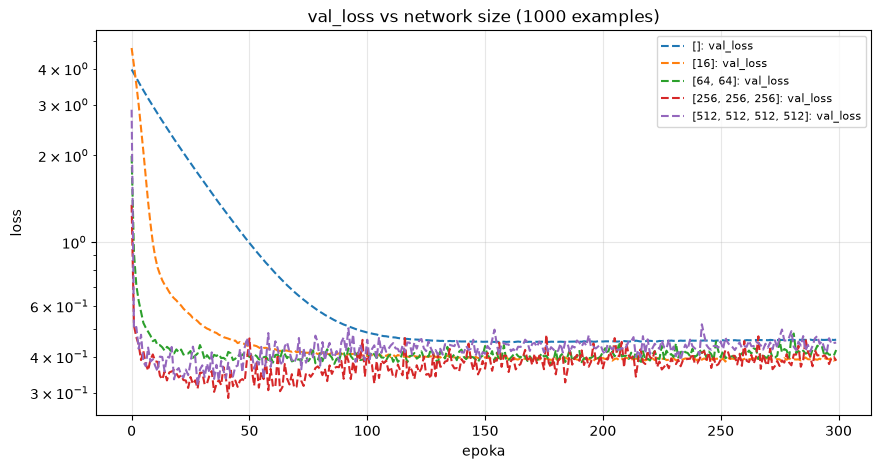

In [33]:
plot_histories(hist15, metric="loss", show_train=False, logy=True,
               title="val_loss vs network size (1000 examples)")
plt.show()

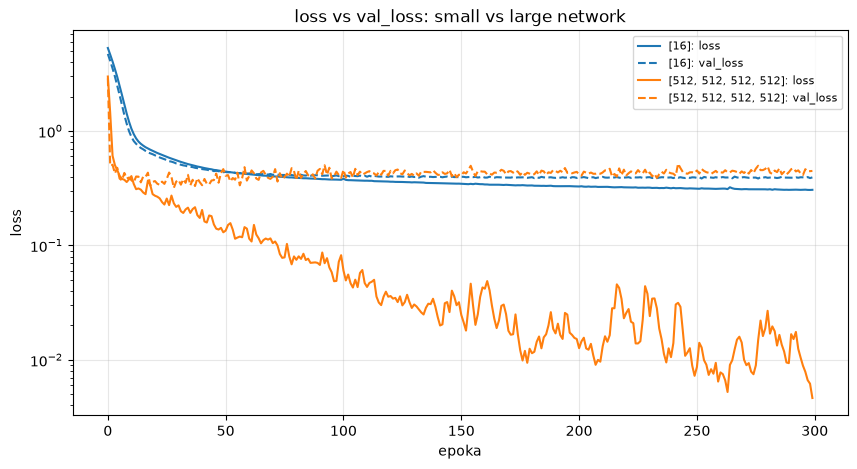

In [34]:
plot_histories({name: hist15[name] for name in ["[16]", "[512, 512, 512, 512]"]},
               metric="loss", logy=True, title="loss vs val_loss: small vs large network")
plt.show()

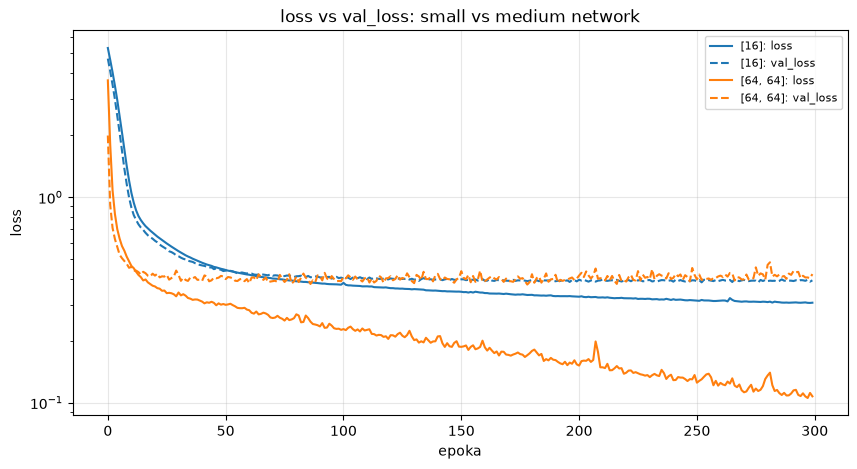

In [35]:
plot_histories({name: hist15[name] for name in ["[16]", "[64, 64]"]},
               metric="loss", logy=True, title="loss vs val_loss: small vs medium network")
plt.show()

**Result:** the large networks reach the lowest val_loss early ([256, 256, 256] ~0.33 around epochs 30–50, [512, 512, 512, 512] ~0.35 around epochs 20–30) and then val_loss slowly rises (to ~0.40 and ~0.45), which is overfitting; small networks learn more slowly but stay stable ([16] ~0.40, the linear model levels off at ~0.46 because it is too simple).

Small network won

# Task 16 — Dropout

Steps:
1. Use a `[256, 256, 256]` network and the same 1,000 samples from Task 15.
2. Train 5 variants with dropout rates of 0.0, 0.1, 0.3, 0.5, and 0.8 for 300 epochs each.
3. Tabulate the final loss, val_loss, their difference, and test MAE.
4. Plot loss and val_loss curves for dropout rates 0.0 and 0.3.
5. Compare three approaches to mitigating overfitting: reducing network capacity, dropout, and early stopping.

### 16.1–16.2 Training with Different Dropout Rates
- Configuration dictionaries differ solely in the `dropout_rate` parameter.
- Reuses `build_models` and `train_models` from Task 15 with no additional code required.

In [36]:
DROPOUTS = [0.0, 0.1, 0.3, 0.5, 0.8]
specs_16 ={}

for drop in DROPOUTS:
    specs_16[drop] = {"hidden_layers": [256, 256, 256], "dropout_rate" :drop}
specs_16

{0.0: {'hidden_layers': [256, 256, 256], 'dropout_rate': 0.0},
 0.1: {'hidden_layers': [256, 256, 256], 'dropout_rate': 0.1},
 0.3: {'hidden_layers': [256, 256, 256], 'dropout_rate': 0.3},
 0.5: {'hidden_layers': [256, 256, 256], 'dropout_rate': 0.5},
 0.8: {'hidden_layers': [256, 256, 256], 'dropout_rate': 0.8}}

In [37]:
set_seed(SEED)
models16 = build_models(specs_16, input_dim=X_small.shape[1])
hist16 = train_models(models16, X_small, y_small, epochs=300)

Training: 0.0
Training: 0.1
Training: 0.3
Training: 0.5
Training: 0.8


### 16.3 Results Table
- Reuses the `summarize_models` function from Task 15.

In [38]:
table16 = results_table(summarize_models(models16, hist16, X_test, y_test), sort_by="MAE")
table16

,model,params,epochs,loss,val_loss,val_loss - loss,MAE,R_2
0,0.5,134145,300,0.2301,0.3154,0.0853,0.4235,0.7147
1,0.3,134145,300,0.1240,0.3021,0.1781,0.4257,0.7003
2,0.1,134145,300,0.0659,0.3440,0.2781,0.4306,0.6867
3,0.0,134145,300,0.0086,0.4142,0.4056,0.4774,0.6247
4,0.8,134145,300,0.4521,0.4381,-0.0140,0.5130,0.5903


model with dropout 0.5 won

### 16.4 Loss and Validation Loss: Dropout 0.0 vs. 0.3
- Four curves: for each model, a solid line (train loss) and a dashed line (val loss) sharing the same color.
- Focus on the gap between the solid and dashed lines.

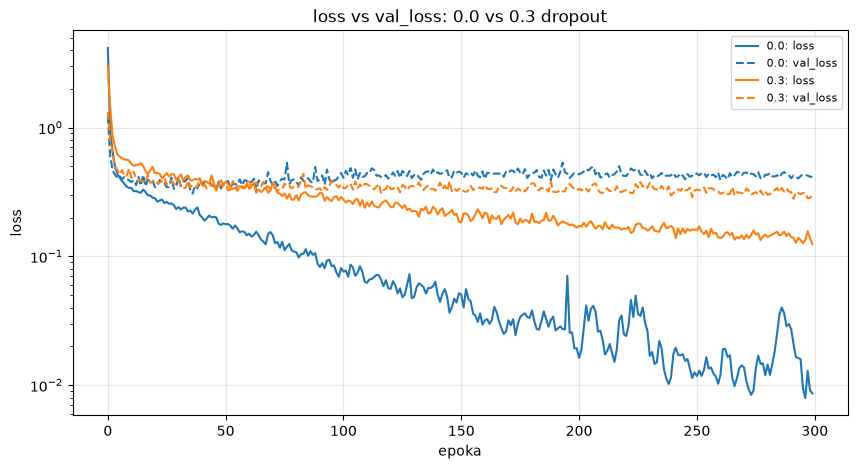

In [39]:
plot_histories({name: hist16[name] for name in [0.0, 0.3]},
               metric="loss", logy=True, title="loss vs val_loss: 0.0 vs 0.3 dropout")
plt.show()

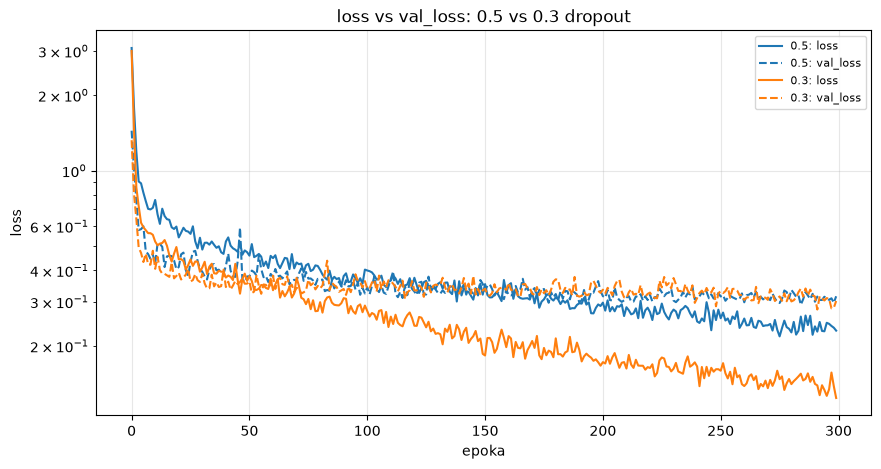

In [40]:
plot_histories({name: hist16[name] for name in [0.5, 0.3]},
               metric="loss", logy=True, title="loss vs val_loss: 0.5 vs 0.3 dropout")
plt.show()

### 16.5 Three Approaches to Mitigating Overfitting
- Smaller network `[16]`: reused model from Task 15.
- Large network with 0.3 dropout: reused model from 16.2.
- Large network with early stopping: the only newly trained model (`patience=20`, restoring best weights).
- Compare test MAE across all three. For early stopping, the `loss` column reflects the final epoch before termination, but the restored weights originate from the best epoch—making test MAE the definitive metric of model quality.

Training: [256, 256, 256] + early stopping


,model,params,epochs,loss,val_loss,val_loss - loss,MAE,R_2
0,"[256, 256, 256] + dropout 0.3",134145,300,0.1240,0.3021,0.1781,0.4257,0.7003
1,"[256, 256, 256] + early stopping",134145,53,0.1362,0.3646,0.2285,0.4335,0.6895
2,[16],161,300,0.3062,0.3933,0.0872,0.4560,0.6838


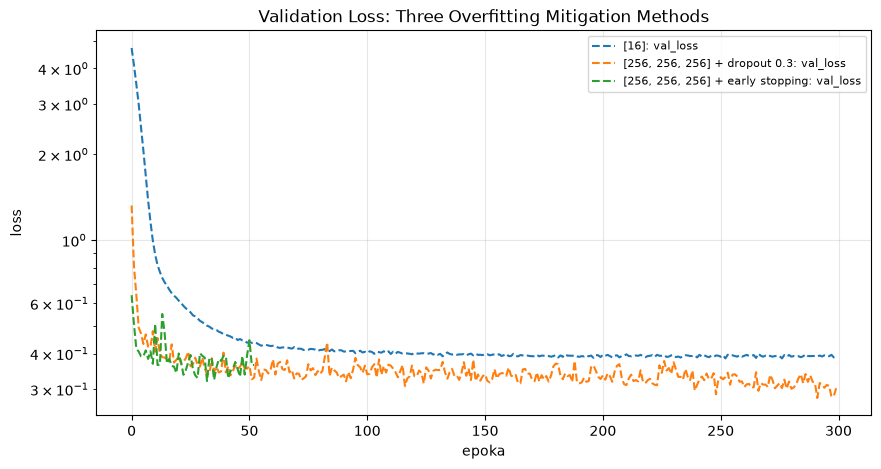

In [41]:
set_seed(SEED)
models_es = build_models({"[256, 256, 256] + early stopping": {"hidden_layers": [256, 256, 256]}},
                         input_dim=X_small.shape[1])
hist_es = train_models(models_es, X_small, y_small, epochs=300, patience=20)

models_cmp = {"[16]": models15["[16]"],
              "[256, 256, 256] + dropout 0.3": models16[0.3],
              **models_es}

hist_cmp = {"[16]": hist15["[16]"],
            "[256, 256, 256] + dropout 0.3": hist16[0.3],
            **hist_es}

table_cmp = results_table(summarize_models(models_cmp, hist_cmp, X_test, y_test), sort_by="MAE")
display(table_cmp)

plot_histories(hist_cmp, metric="loss", show_train=False, logy=True,
               title="Validation Loss: Three Overfitting Mitigation Methods")
plt.show()

model [256, 256, 256] + dropout 0.3] is the best

# Task 17 — Titanic: data preprocessing pipeline

Steps:
1. Load the Titanic dataset.
2. Look at the data: size, column types, missing values, how many survived.
3. Build a preprocessing pipeline: select 7 features, fill missing values, one-hot encode text columns, scale numbers, split stratified by the target.
4. Compute classical baselines: DummyClassifier and LogisticRegression.
5. Answer the questions.

### 17.1–17.2 Loading and exploring
- `load_titanic` downloads the dataset from OpenML (1309 passengers).
- `explore_titanic` prints the four things we need to know before preprocessing: shape, column types, missing values per column and the share of survivors.

In [42]:
from sklearn.datasets import fetch_openml

In [43]:
def load_titanic():
    """Downloads the Titanic dataset from OpenML as a DataFrame."""
    return fetch_openml("titanic", version=1, as_frame=True).frame


def explore_titanic(df):
    """Prints dataset size, column types, missing values per column and the target distribution."""
    print("Shape (rows, columns):", df.shape)
    print("\nColumn types:\n", df.dtypes)
    print("\nMissing values per column:\n", df.isna().sum())
    print("\nTarget distribution (survived, share):\n", df["survived"].value_counts(normalize=True).round(3))

In [44]:
titanic = load_titanic()
explore_titanic(titanic)

Shape (rows, columns): (1309, 14)

Column types:
 pclass          int64
survived     category
name              str
sex          category
age           float64
sibsp           int64
parch           int64
ticket            str
fare          float64
cabin             str
embarked     category
boat              str
body          float64
home.dest         str
dtype: object

Missing values per column:
 pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

Target distribution (survived, share):
 survived
0    0.618
1    0.382
Name: proportion, dtype: float64


In [45]:
titanic

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


**Result:** 1309 passengers, 38 % survived, so the classes are imbalanced; `age` is missing in 263 rows, `embarked` in 2 and `fare` in 1.

### 17.3 Preprocessing pipeline
- `select_features` picks the 7 features and the target (`survived` comes from OpenML as text "0"/"1", so it is converted to int).
- Numeric columns (`age`, `sibsp`, `parch`, `fare`): fill missing values with the median → `StandardScaler`.
- Categorical columns (`sex`, `embarked`, `pclass`): fill missing values with the most frequent value → `OneHotEncoder`. `pclass` is treated as a category: class 1, 2 and 3 are groups, not distances.
- `make_preprocessor` joins both pipelines in a `ColumnTransformer`.
- `prepare_titanic` splits the data stratified by `survived`, fits the preprocessor **only on the training part** and transforms both parts. Fitting on all data would leak information about the test set into the model.
- `fare` also has missing values in the OpenML version, so the median imputer is applied to all numeric columns, not only `age`.

In [46]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [47]:
NUMERIC_FEATURES = ["age", "sibsp", "parch", "fare"]
CATEGORICAL_FEATURES = ["sex", "embarked", "pclass"]
TARGET = "survived"

def select_features(df):
    """Picks the 7 model features (X) and the target as integers 0/1 (y)."""
    return df[NUMERIC_FEATURES + CATEGORICAL_FEATURES], df[TARGET].astype(int)

def make_preprocessor():
    """ColumnTransformer: numeric -> median + scaling, categorical -> most frequent + one-hot."""
    numeric = Pipeline([("impute", SimpleImputer(strategy="median")),
                        ("scale", StandardScaler())])
    
    categorical = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
    
    return ColumnTransformer([("numeric", numeric, NUMERIC_FEATURES),
                              ("categorical", categorical, CATEGORICAL_FEATURES)])

def prepare_titanic():
    """Titanic train/test arrays ready for a neural network: X_train, X_test, y_train, y_test.

    Stratified split by 'survived'; the preprocessor is fitted on the training part only.
    """
    X, y = select_features(load_titanic())
    X_train, X_test, y_train, y_test = split_data(X, y, stratify=True)
    preprocessor = make_preprocessor().fit(X_train)
    return (preprocessor.transform(X_train), preprocessor.transform(X_test),
            y_train.to_numpy(), y_test.to_numpy())

In [48]:
X_train_t, X_test_t, y_train_t, y_test_t = prepare_titanic()

print("Train:", X_train_t.shape, " Test:", X_test_t.shape)
print("Survived in train: %.3f, in test: %.3f" % (y_train_t.mean(), y_test_t.mean()))

Train: (1047, 12)  Test: (262, 12)
Survived in train: 0.382, in test: 0.382


### 17.4 Classical baselines
- `fit_classic_baselines` trains `DummyClassifier(strategy='most_frequent')` (always predicts "did not survive") and `LogisticRegression()`.
- `evaluate_classifier` returns accuracy and ROC AUC on the test set; it works for sklearn models and PyTorch networks.
- `evaluate_models` makes one row per model.

In [49]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

def fit_classic_baselines(X_train, y_train):
    """Trains the classical baselines: DummyClassifier (most frequent class) and LogisticRegression."""
    return {
        "Dummy (most frequent)": DummyClassifier(strategy="most_frequent").fit(X_train, y_train),
        "LogisticRegression": LogisticRegression(max_iter=1000).fit(X_train, y_train),
    }

def evaluate_classifier(model, X_test, y_test):
    """Accuracy (threshold 0.5) and ROC AUC on the test set."""
    proba = predict_proba(model, X_test)
    return {"accuracy": accuracy_score(y_test, proba >= 0.5), "ROC AUC": roc_auc_score(y_test, proba)}


def evaluate_models(models, X_test, y_test):
    """One row of evaluate_classifier results per model."""
    rows = []
    
    for name, model in models.items():
        metrics = evaluate_classifier(model, X_test, y_test)
        
        row = {"model": name}
        
        row.update(metrics)
        
        rows.append(row)
        
    return rows

In [50]:
baselines17 = fit_classic_baselines(X_train_t, y_train_t)

In [51]:
table17 = results_table(evaluate_models(baselines17, X_test_t, y_test_t), sort_by="ROC AUC", ascending=False)
table17

,model,accuracy,ROC AUC
0,LogisticRegression,0.8053,0.8673
1,Dummy (most frequent),0.6183,0.5000


**Result:** LogisticRegression reaches accuracy 0.8 and ROC AUC 0.86, while the Dummy model has accuracy 0.61 (the share of non-survivors) and ROC AUC 0.5, so any network in task 18 has to beat 0.8 to be useful.

### 17.5 Answers

**Why impute `age` with the median rather than the mean?**
- The age distribution is skewed: most passengers are young adults, with a long tail of older people and many children.

**Why is `stratify=y` critical here?**
- The classes are imbalanced (about 38% survived) and the dataset is small (~260 passengers in the test set).
- A random split can, by chance, put a different share of survivors in train and test. Then the test accuracy and the baseline would be measured on a different class balance than the model was trained on.
- `stratify=y` keeps the same share of survivors in both parts, so the results are comparable between runs and models.

**What is the accuracy of a classifier that predicts "did not survive" for everyone?**
- It equals the share of passengers who died: about 62% (809 of 1309 in the OpenML version). The Dummy row in the table shows the exact value on our test set.

# Task 18 — Titanic: architecture, activation and dropout grid search

Steps:
1. Train 24 networks: every combination of depth (1, 2, 3 layers), width (16, 64), activation (relu, tanh) and dropout (0.0, 0.3), with early stopping (`patience=15`).
2. Show a table with parameters, stopped epoch, test accuracy and ROC AUC, sorted by ROC AUC.
3. For the best model: confusion matrix and classification report.
4. Find the decision threshold that maximizes F1 and compare it with 0.5.

The output layer is `Linear(n, 1)` with `BCEWithLogitsLoss`, the PyTorch equivalent of `Dense(1, activation="sigmoid")` with `binary_crossentropy` (see the toolkit section).

### 18.1–18.2 Grid search
- `make_grid_specs` creates all 24 combinations with `itertools.product`; a depth of 2 and a width of 16 means hidden layers `[16, 16]`.
- `summarize_classifier` makes one result row: parameters, the epoch where early stopping stopped, accuracy and ROC AUC.
- `run_titanic_experiment` only connects the steps: specs → `build_models` → `train_models` → table. It returns the table, the models and their histories.
- At most 300 epochs; early stopping usually ends training much earlier.

In [52]:
import itertools
from itertools import product

In [53]:
def make_grid_specs(depths, widths, activations, dropouts):
    """build_models settings for every combination of depth, width, activation and dropout."""
    specs = {}
    for depth, width, activation, dropout in itertools.product(depths, widths, activations, dropouts):
        name = f"{depth}x{width} {activation} dropout={dropout}"
        specs[name] = {"hidden_layers": [width] * depth, "activation": activation,
                       "dropout_rate": dropout, "output_units": 1}
    return specs

def summarize_classifier(name, model, history, X_test, y_test):
    """One result row: parameters, stopped epoch, test accuracy and ROC AUC."""
    row = {"model": name, "params": count_params(model), "stopped epoch": len(history["loss"])}
    row.update(evaluate_classifier(model, X_test, y_test))
    return row


def summarize_classifiers(models, histories, X_test, y_test):
    """List of result rows, one per model."""
    rows = []
    for name, model in models.items():
        rows.append(summarize_classifier(name, model, histories[name], X_test, y_test))
    return rows

def run_titanic_experiment(data, depths, widths, activations, dropouts, epochs=300, patience=15):
    """Grid search on Titanic: returns (results table sorted by ROC AUC, models, histories)."""
    X_train, X_test, y_train, y_test = data
    specs = make_grid_specs(depths, widths, activations, dropouts)
    models = build_models(specs, input_dim=X_train.shape[1])
    histories = train_models(models, X_train, y_train, epochs=epochs, patience=patience,
                             loss="binary_crossentropy", metrics=["accuracy"])
    rows = summarize_classifiers(models, histories, X_test, y_test)
    return results_table(rows, sort_by="ROC AUC", ascending=False), models, histories

### Why `loss="binary_crossentropy"`?

**Titanic is binary classification:** the answer is 0 (died) or 1 (survived), and the network outputs one number, the probability of survival.

- **What it measures:** how far the predicted probability `p` is from the true label.
  Formula: `-[y·log(p) + (1−y)·log(1−p)]`.
- **It punishes confident mistakes hard:** the passenger survived (y = 1) and the model says
  - `p = 0.9` → loss 0.11 (good),
  - `p = 0.5` → loss 0.69 (unsure),
  - `p = 0.1` → loss 2.30 (confident and wrong, big penalty).
- **Why not MSE:** with a sigmoid, MSE gives very small gradients when the model is confidently wrong, so it learns slowly. Crossentropy gives a large gradient in that case and fixes the mistake quickly.
- **In PyTorch:** `binary_crossentropy` maps to `nn.BCEWithLogitsLoss`. The network outputs one logit (no sigmoid) and the loss applies the sigmoid itself. It is the same model as `Dense(1, activation="sigmoid")` in Keras, but numerically more stable.
- **`metrics=["accuracy"]`** is only computed and reported; the network learns from the loss.

**Remember:** 2 classes → binary crossentropy, many classes → (sparse) categorical crossentropy, numbers → MSE.

In [54]:
set_seed(SEED)
titanic_data = (X_train_t, X_test_t, y_train_t, y_test_t)
table18, models18, hist18 = run_titanic_experiment(titanic_data, depths=[1, 2, 3], widths=[16, 64],
                                                   activations=["relu", "tanh"], dropouts=[0.0, 0.3])
table18

Training: 1x16 relu dropout=0.0


C:\Users\litwi\AppData\Local\Temp\ipykernel_4344\2065882772.py:8: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y = torch.as_tensor(np.asarray(y), dtype=torch.float32).reshape(len(y), -1)


Training: 1x16 relu dropout=0.3
Training: 1x16 tanh dropout=0.0
Training: 1x16 tanh dropout=0.3
Training: 1x64 relu dropout=0.0
Training: 1x64 relu dropout=0.3
Training: 1x64 tanh dropout=0.0
Training: 1x64 tanh dropout=0.3
Training: 2x16 relu dropout=0.0
Training: 2x16 relu dropout=0.3
Training: 2x16 tanh dropout=0.0
Training: 2x16 tanh dropout=0.3
Training: 2x64 relu dropout=0.0
Training: 2x64 relu dropout=0.3
Training: 2x64 tanh dropout=0.0
Training: 2x64 tanh dropout=0.3
Training: 3x16 relu dropout=0.0
Training: 3x16 relu dropout=0.3
Training: 3x16 tanh dropout=0.0
Training: 3x16 tanh dropout=0.3
Training: 3x64 relu dropout=0.0
Training: 3x64 relu dropout=0.3
Training: 3x64 tanh dropout=0.0
Training: 3x64 tanh dropout=0.3


,model,params,stopped epoch,accuracy,ROC AUC
0,3x16 relu dropout=0.3,769,89,0.8626,0.8851
1,1x64 relu dropout=0.0,897,37,0.8588,0.8806
2,1x64 relu dropout=0.3,897,42,0.8359,0.8799
3,2x16 tanh dropout=0.0,497,50,0.8435,0.8797
4,3x64 tanh dropout=0.3,9217,33,0.8359,0.8782
5,3x64 tanh dropout=0.0,9217,29,0.8321,0.8773
6,3x16 relu dropout=0.0,769,33,0.8321,0.8771
7,2x64 tanh dropout=0.3,5057,46,0.8282,0.8761
8,3x64 relu dropout=0.3,9217,29,0.8473,0.8759
9,1x16 relu dropout=0.0,225,46,0.8244,0.8756


**Result:** the best ROC AUC (0.88) has `3x16 relu dropout=0.3`

### 18.3 Best model: confusion matrix and classification report
- The best model is the first row of the table.
- `confusion_table` labels the rows (true class) and columns (predicted class).
- `plot_histories` shows where early stopping stopped: after the lowest `val_loss`, training ran `patience` more epochs, and the best weights were restored.

In [55]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [56]:
def confusion_table(y_true, y_pred):
    """Confusion matrix as a table: rows = true class, columns = predicted class."""
    labels = ["died", "survived"]
    return pd.DataFrame(confusion_matrix(y_true, y_pred),
                        index=[f"true: {l}" for l in labels],
                        columns=[f"predicted: {l}" for l in labels])

Best model: 3x16 relu dropout=0.3


,predicted: died,predicted: survived
true: died,151,11
true: survived,25,75


              precision    recall  f1-score   support

        died       0.86      0.93      0.89       162
    survived       0.87      0.75      0.81       100

    accuracy                           0.86       262
   macro avg       0.87      0.84      0.85       262
weighted avg       0.86      0.86      0.86       262



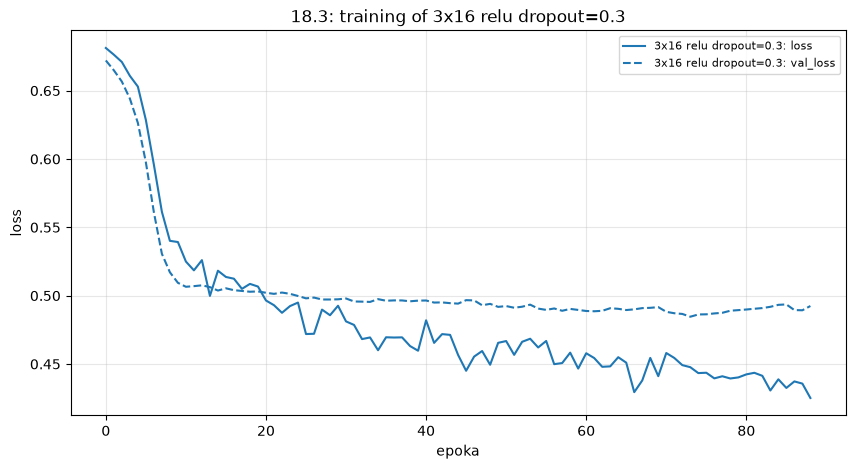

In [57]:
best_name = table18.loc[0, "model"]
best_model = models18[best_name]
y_pred_best = predict_labels(best_model, X_test_t)

print("Best model:", best_name)
display(confusion_table(y_test_t, y_pred_best))
print(classification_report(y_test_t, y_pred_best, target_names=["died", "survived"]))

plot_histories({best_name: hist18[best_name]}, metric="loss", title=f"18.3: training of {best_name}")
plt.show()

**Result:** the best model (`3x16 relu dropout=0.3`, accuracy 0.86) recognizes 93% of the passengers who died (151 of 162, recall 0.93) but only 75% of the survivors (75 of 100, recall 0.75), so most of its mistakes are survivors predicted as "died" (25 vs 11 the other way).

### 18.4 Decision threshold
- `f1_by_threshold` computes F1 for thresholds 0.10, 0.15, …, 0.90.
- `find_best_threshold` picks the threshold with the highest F1 on the **validation** part (the last 20% of the training data, the same part early stopping used). The test set is not used for choosing, otherwise the test score would be too optimistic.
- Then we compare F1 on the test set at the chosen threshold and at the default 0.5.

In [58]:
from sklearn.metrics import f1_score

In [59]:
THRESHOLDS = np.round(np.arange(0.10, 0.91, 0.05), 2)


def f1_by_threshold(model, X, y, thresholds=THRESHOLDS):
    """F1-score for every threshold, as a table."""
    proba = predict_proba(model, X)
    scores = [f1_score(y, (proba >= t).astype(int)) for t in thresholds]
    return pd.DataFrame({"threshold": thresholds, "F1": scores})


def find_best_threshold(model, X_val, y_val):
    """Threshold between 0.1 and 0.9 with the highest F1 on the validation data."""
    table = f1_by_threshold(model, X_val, y_val)
    return table.loc[table["F1"].idxmax(), "threshold"]

In [60]:
(_, _), (X_val_t, y_val_t) = split_validation(X_train_t, y_train_t, validation_split=0.2)
best_threshold = find_best_threshold(best_model, X_val_t, y_val_t)

f1_default = f1_score(y_test_t, predict_labels(best_model, X_test_t, threshold=0.5))
f1_tuned = f1_score(y_test_t, predict_labels(best_model, X_test_t, threshold=best_threshold))
print(f"Best threshold on validation: {best_threshold}")
print(f"Test F1 at 0.5: {f1_default:.3f}   Test F1 at {best_threshold}: {f1_tuned:.3f}")

Best threshold on validation: 0.25
Test F1 at 0.5: 0.806   Test F1 at 0.25: 0.745


**Result:** the threshold 0.5 gives test F1 ___ compared with ___ at 0.5; a threshold below 0.5 predicts "survived" more often, which helps the minority class.

# Task 19 — Iris: dropout failure on a small dataset


Steps:
1. Load Iris (150 flowers, 4 features, 3 species), split with stratification, scale.
2. Train three networks for 200 epochs: `[8]`, `[128, 128]`, `[128, 128]` with dropout 0.5.
3. Repeat for 5 random seeds and report mean test accuracy ± standard deviation.
4. Compare with `RandomForestClassifier` on the same split.

Output layer: `Linear(n, 3)` with `CrossEntropyLoss`, the PyTorch equivalent of `Dense(3, activation="softmax")` with `sparse_categorical_crossentropy`. The networks train on all 120 training flowers (`validation_split=0`), like the Random Forest, because there is no early stopping to feed.

### 19.1 Data
- `as_dataset` packs the four arrays and the task type into one dictionary. Task 20 uses the same format for all three datasets.
- `load_iris_data` splits 80/20 with stratification (10 flowers of each species in the test set) and scales the features.

In [63]:
from sklearn.datasets import load_iris

In [64]:
def as_dataset(splits, task):
    """(X_train, X_test, y_train, y_test) + task type -> one dictionary."""
    X_train, X_test, y_train, y_test = splits
    return {"X_train": X_train, "X_test": X_test, "y_train": np.asarray(y_train),
            "y_test": np.asarray(y_test), "task": task}


def load_iris_data():
    """Iris split 80/20 with stratification and scaled, as a multiclass dataset."""
    iris = load_iris(as_frame=True)
    X_train, X_test, y_train, y_test = split_data(iris.data, iris.target, stratify = True)
    X_train, X_test = scale_features(X_train, X_test)
    return as_dataset(splits=(X_train, X_test, y_train, y_test), task='multiclass')

In [65]:
iris_data = load_iris_data()
print("Train:", iris_data["X_train"].shape, " Test:", iris_data["X_test"].shape)
print("Test samples per class:", np.bincount(iris_data["y_test"]))

Train: (120, 4)  Test: (30, 4)
Test samples per class: [10 10 10]


### 19.2–19.3 Three networks × 5 seeds
- Configurations are written as `{name: (hidden layers, dropout)}`, the format task 20 uses. `configs_to_specs` turns them into `build_models` settings.
- `TASK_SETTINGS` holds the loss and metric for each task type, so one set of functions works for regression, binary and multiclass.
- `score_model` computes the task metric on the test set: R² (regression), ROC AUC (binary) or accuracy (multiclass).
- `score_seed` sets one seed, builds and trains all configurations and returns their scores.
- `scores_over_seeds` repeats it for each seed; `aggregate_scores` computes the mean and standard deviation.
- Only the seed changes between runs: the split is the same, so the spread comes from weight initialization and batch order.

In [66]:
TASK_SETTINGS = {
    "regression": {"loss": "mse", "metrics": ["mae"]},
    "binary": {"loss": "binary_crossentropy", "metrics": ["accuracy"]},
    "multiclass": {"loss": "sparse_categorical_crossentropy", "metrics": ["accuracy"]},
}


def output_units(data):
    """Number of network outputs: one per class for multiclass, otherwise 1."""
    if data["task"] == "multiclass":
        n_classes = len(np.unique(data["y_train"]))   # e.g. Iris: [0, 1, 2] -> 3
        return n_classes
    return 1    

def configs_to_specs(configs, n_outputs):
    """{name: (hidden layers, dropout)} -> {name: build_models settings}."""
    specs = {}
    for name, (layers, dropout) in configs.items():
        specs[name] = {
            "hidden_layers": layers,       # e.g. [64, 32]
            "dropout_rate": dropout,       # e.g. 0.3
            "output_units": n_outputs,     # 1 or number of classes, from output_units(data)
        }
    return specs

def score_model(model, data):
    """Task metric on the test set: R² (regression), ROC AUC (binary) or accuracy (multiclass)."""
    X, y = data["X_test"], data["y_test"]
    if data["task"] == "regression":
        return r2_score(y, predict(model, X))
    if data["task"] == "binary":
        return roc_auc_score(y, predict_proba(model, X))
    return accuracy_score(y, predict_labels(model, X))

In [68]:
def score_seed(specs, data, seed, epochs, patience=None, validation_split=0.2):
    """Scores of all configurations for one seed: {name: test score}."""
    set_seed(seed)                                       # same seed -> same starting weights

    X_train, y_train = data["X_train"], data["y_train"]
    settings = TASK_SETTINGS[data["task"]]               # e.g. {"loss": "binary_crossentropy", "metrics": ["accuracy"]}

    models = build_models(specs, input_dim=X_train.shape[1])
    train_models(models, X_train, y_train, epochs=epochs, patience=patience,
                 validation_split=validation_split,
                 loss=settings["loss"], metrics=settings["metrics"])

    scores = {}
    for name, model in models.items():
        scores[name] = score_model(model, data)          # R², ROC AUC or accuracy on the test set
    return scores


def scores_over_seeds(specs, data, seeds, epochs, patience=None, validation_split=0.2):
    """Long table with one row per (seed, model) and its test score."""
    rows = []
    for seed in seeds:
        scores = score_seed(specs, data, seed, epochs, patience, validation_split)
        rows += [{"seed": seed, "model": name, "score": value} for name, value in scores.items()]
    return pd.DataFrame(rows)


def aggregate_scores(scores):
    """Mean and standard deviation of the score for each model."""
    rows = []
    for name in scores["model"].unique():                          # each model once, in original order
        model_scores = scores[scores["model"] == name]["score"]    # this model's scores from all seeds
        rows.append({"model": name,
                     "mean": model_scores.mean(),
                     "std": model_scores.std()})
    return pd.DataFrame(rows)


### 19.4 Random Forest on the same split
- `BASELINES` holds the classical model for each task type: Ridge for regression, LogisticRegression for binary, Random Forest for multiclass.
- `baseline_scores` trains the classical model once per seed, in the same long-table format, so it can be aggregated together with the networks.

In [75]:
from sklearn.ensemble import RandomForestClassifier
BASELINE_NAMES = {"regression": "Ridge", "binary": "LogisticRegression", "multiclass": "RandomForest"}


def make_baseline(task, seed):
    """New, untrained classical model for the given task type."""
    if task == "regression":
        return Ridge()
    if task == "binary":
        return LogisticRegression(max_iter=1000)
    return RandomForestClassifier(random_state=seed)      # multiclass


def baseline_scores(data, seeds):
    """Classical baseline score for every seed, in the same format as scores_over_seeds."""
    name = BASELINE_NAMES[data["task"]]
    rows = []
    for seed in seeds:
        model = make_baseline(data["task"], seed).fit(data["X_train"], data["y_train"])
        rows.append({"seed": seed, "model": name, "score": score_model(model, data)})
    return pd.DataFrame(rows)

In [76]:
SEEDS_19 = [0, 1, 2, 3, 4]
CONFIGS_19 = {
    "[8]": ([8], 0.0),
    "[128, 128]": ([128, 128], 0.0),
    "[128, 128] dropout 0.5": ([128, 128], 0.5),
}

specs19 = configs_to_specs(CONFIGS_19, output_units(iris_data))
scores19 = scores_over_seeds(specs19, iris_data, SEEDS_19, epochs=200, validation_split=0.0)
scores19 = pd.concat([scores19, baseline_scores(iris_data, SEEDS_19)])

table19 = aggregate_scores(scores19).rename(columns={"mean": "mean accuracy", "std": "std"})
results_table(table19.to_dict("records"), sort_by="mean accuracy", ascending=False)

Training: [8]
Training: [128, 128]
Training: [128, 128] dropout 0.5
Training: [8]
Training: [128, 128]
Training: [128, 128] dropout 0.5
Training: [8]
Training: [128, 128]
Training: [128, 128] dropout 0.5
Training: [8]
Training: [128, 128]
Training: [128, 128] dropout 0.5
Training: [8]
Training: [128, 128]
Training: [128, 128] dropout 0.5


,model,mean accuracy,std
0,"[128, 128] dropout 0.5",0.9667,0.0000
1,"[128, 128]",0.9600,0.0149
2,RandomForest,0.9467,0.0183
3,[8],0.9133,0.0298


**Result:** the best mean accuracy (0.96) has 128, 128 and the Random Forest reaches 0.94 without any tuning.

# Task 20 — Final benchmark

Steps:
1. Write `benchmark_dataset`, which trains several configurations over several seeds and reports mean ± standard deviation.
2. Run it on all three datasets: California Housing (R²), Titanic (ROC AUC), Iris (accuracy).
3. Use the same five configurations everywhere.
4. Join the results into one table with the classical baseline.

All networks train with early stopping (`patience=15`, at most 200 epochs) and 3 seeds, to keep the running time manageable on a CPU. The functions from task 19 are reused; only the joining code is new.

### 20.1 Benchmark functions
- `params_per_config`: parameter count of each configuration (depends on the dataset's number of inputs and outputs).
- `format_score`: "mean ± std" as text.
- `benchmark_dataset`: scores over seeds → mean and std → one row per configuration with the dataset name, parameters and the baseline score.
- `benchmark_all`: runs `benchmark_dataset` for each dataset and joins the tables.

In [ ]:
def params_per_config(specs, input_dim):
    """Parameter count of every configuration: {name: number of parameters}."""
    return {name: count_params(build_model(input_dim, **settings)) for name, settings in specs.items()}


def format_score(mean, std):
    """'mean ± std' with 3 decimals."""
    return f"{mean:.3f} ± {std:.3f}"

